In [1]:
import pandas as pd

In [2]:
# Path to GLSEA SST data
usace_file = '/Users/ljob/Desktop/Data/USACE/ForecasterPick_merged.csv'
nbs_p_file = '/Users/ljob/Desktop/CNBS_forecast_ver_anom_sst_swe.csv'

#ver_file = 'CNBS_forecast_ver.csv'
#bias_file = 'CNBS_forecast_ver_swe.csv'

existing_model_data = pd.read_csv(usace_file,sep='\t')
my_model_data = pd.read_csv(nbs_p_file,sep='\t')


In [51]:
print(existing_model_data)

    forecast_date  year_month  superior_nbs  michigan-huron_nbs    erie_nbs  \
0      2017-01-01  2017-01-01    -11.632032           33.472882  103.556119   
1      2017-01-01  2017-02-01      5.654889           51.680816  148.952809   
2      2017-01-01  2017-03-01     49.846677          115.519358  301.306537   
3      2017-01-01  2017-04-01    146.868194          176.851714  280.157654   
4      2017-01-01  2017-05-01    174.754169          152.805332  163.615787   
..            ...         ...           ...                 ...         ...   
589    2025-03-01  2025-04-01    130.711368          175.677594  273.606704   
590    2025-03-01  2025-05-01    154.979715          150.617137  180.755117   
591    2025-03-01  2025-06-01    141.173575          118.795709  115.408228   
592    2025-03-01  2025-07-01    111.872775           68.830645   30.533932   
593    2025-03-01  2025-08-01     89.156101           32.064638  -56.170913   

     ontario_nbs  
0     160.677350  
1     159.889

In [50]:
print(my_model_data)

         cfs_run model forecast_month  erie_evaporation    erie_nbs  \
0     2011-04-01    GP        2011-04         15.641490  350.669241   
1     2011-04-01    GP        2011-05         34.382500  279.664150   
2     2011-04-01    GP        2011-06         54.636333  146.629898   
3     2011-04-01    GP        2011-07         91.450659   45.356513   
4     2011-04-01    GP        2011-08        128.930333 -112.089918   
...          ...   ...            ...               ...         ...   
5971  2022-11-01   XGB        2022-12         89.475361  110.555197   
5972  2022-12-01    GP        2022-12         95.354164  169.995363   
5973  2022-12-01    NN        2022-12        104.822697  231.859266   
5974  2022-12-01    RF        2022-12         96.111349  149.559931   
5975  2022-12-01   XGB        2022-12         83.525792  156.425707   

      erie_precipitation  erie_runoff  michigan-huron_evaporation  \
0             117.534589   144.700285                    3.223602   
1        

In [3]:
import pandas as pd
import numpy as np


# ----------------------------
# METRICS
# ----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot == 0:
        return np.nan

    return 1 - (ss_res / ss_tot)


def bias(y_true, y_pred):
    # positive = model overpredicts
    # negative = model underpredicts
    return np.mean(y_pred - y_true)


def calc_metrics(g):
    return pd.Series({
        "my_rmse": rmse(g["obs"], g["forecast"]),
        "existing_rmse": rmse(g["obs"], g["existing_forecast"]),

        "my_r2": r2_score(g["obs"], g["forecast"]),
        "existing_r2": r2_score(g["obs"], g["existing_forecast"]),

        "my_bias": bias(g["obs"], g["forecast"]),
        "existing_bias": bias(g["obs"], g["existing_forecast"]),
    })


def add_improvement_columns(df, existing_model_name="existing_model"):
    df = df.copy()

    # RMSE: lower is better
    df["rmse_improvement_pct"] = (
        (df["existing_rmse"] - df["my_rmse"])
        / df["existing_rmse"]
        * 100
    )

    # R2: higher is better
    df["r2_improvement"] = df["my_r2"] - df["existing_r2"]

    # Bias: closer to zero is better
    df["bias_improvement_pct"] = np.where(
        np.abs(df["existing_bias"]) == 0,
        np.nan,
        (
            (np.abs(df["existing_bias"]) - np.abs(df["my_bias"]))
            / np.abs(df["existing_bias"])
            * 100
        )
    )

    df["rmse_winner"] = np.where(
        df["rmse_improvement_pct"] > 0,
        "my_model",
        existing_model_name
    )

    df["r2_winner"] = np.where(
        df["r2_improvement"] > 0,
        "my_model",
        existing_model_name
    )

    df["bias_winner"] = np.where(
        df["bias_improvement_pct"] > 0,
        "my_model",
        existing_model_name
    )

    return df


# ----------------------------
# STANDARDIZE EXISTING MODEL
# ----------------------------
def standardize_existing_nbs_model(
    existing_df,
    date_col="forecast_date",
    month_col="year_month",
    model_name="existing_model"
):
    df = existing_df.copy()

    df = df.rename(columns={
        date_col: "cfs_run",
        month_col: "forecast_month"
    })

    df["cfs_run"] = pd.to_datetime(df["cfs_run"])
    df["forecast_month"] = pd.to_datetime(df["forecast_month"])
    df["existing_model"] = model_name

    return df


# ----------------------------
# MELT YOUR MODEL DATA
# ----------------------------
def melt_my_nbs_model(my_df):
    df = my_df.copy()

    df["cfs_run"] = pd.to_datetime(df["cfs_run"])
    df["forecast_month"] = pd.to_datetime(df["forecast_month"])

    id_cols = ["cfs_run", "forecast_month", "model"]

    nbs_cols = [
        c for c in df.columns
        if c.endswith("_nbs") or c.endswith("_nbs_obs")
    ]

    long = df.melt(
        id_vars=id_cols,
        value_vars=nbs_cols,
        var_name="variable",
        value_name="value"
    )

    long["type"] = np.where(
        long["variable"].str.endswith("_obs"),
        "obs",
        "forecast"
    )

    long["variable"] = long["variable"].str.replace("_obs", "", regex=False)

    split = long["variable"].str.split("_", n=1, expand=True)
    long["lake"] = split[0]
    long["component"] = split[1]

    wide = (
        long
        .pivot_table(
            index=["cfs_run", "forecast_month", "model", "lake", "component"],
            columns="type",
            values="value"
        )
        .reset_index()
    )

    return wide


# ----------------------------
# MELT EXISTING MODEL DATA
# ----------------------------
def melt_existing_nbs_model(existing_df):
    df = existing_df.copy()

    id_cols = ["cfs_run", "forecast_month", "existing_model"]

    nbs_cols = [
        c for c in df.columns
        if c.endswith("_nbs")
    ]

    long = df.melt(
        id_vars=id_cols,
        value_vars=nbs_cols,
        var_name="variable",
        value_name="existing_forecast"
    )

    split = long["variable"].str.split("_", n=1, expand=True)
    long["lake"] = split[0]
    long["component"] = split[1]

    return long.drop(columns="variable")


# ----------------------------
# COMPARE YOUR MODEL TO EXISTING NBS MODEL
# ----------------------------
def compare_my_model_to_existing_nbs(
    my_df,
    existing_df,
    existing_model_name="existing_model"
):
    """
    Compares your NBS forecasts to an existing NBS-only model.

    Positive rmse_improvement_pct:
        Your model has lower RMSE.

    Positive r2_improvement:
        Your model has higher R2.

    Positive bias_improvement_pct:
        Your model has bias closer to zero.
    """

    existing_standard = standardize_existing_nbs_model(
        existing_df,
        model_name=existing_model_name
    )

    my_long = melt_my_nbs_model(my_df)
    existing_long = melt_existing_nbs_model(existing_standard)

    merged = my_long.merge(
        existing_long,
        on=["cfs_run", "forecast_month", "lake", "component"],
        how="inner"
    )

    merged = merged.dropna(subset=["forecast", "obs", "existing_forecast"])

    comparison = (
        merged
        .groupby(["model", "lake", "component"])
        .apply(calc_metrics)
        .reset_index()
    )

    comparison = add_improvement_columns(
        comparison,
        existing_model_name=existing_model_name
    )

    comparison = comparison.sort_values(
        "rmse_improvement_pct",
        ascending=False
    )

    overall = (
        merged
        .groupby("model")
        .apply(calc_metrics)
        .reset_index()
    )

    overall = add_improvement_columns(
        overall,
        existing_model_name=existing_model_name
    )

    overall = overall.sort_values(
        "rmse_improvement_pct",
        ascending=False
    )

    return comparison, overall


# ----------------------------
# USAGE
# ----------------------------
comparison, overall = compare_my_model_to_existing_nbs(
    my_df=my_model_data,
    existing_df=existing_model_data,
    existing_model_name="existing_model"
)

print("\n=== NBS Skill by Model/Lake/Component ===")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(comparison)


=== NBS Skill by Model/Lake/Component ===
   model            lake component     my_rmse  existing_rmse     my_r2  \
10    RF         ontario       nbs  109.532190     112.606889  0.508806   
9     RF  michigan-huron       nbs   45.688204      45.977396  0.607893   
11    RF        superior       nbs   48.280100      48.291734  0.567973   
8     RF            erie       nbs  110.630049     110.257696  0.465596   
3     GP        superior       nbs   53.947888      48.291734  0.460585   
2     GP         ontario       nbs  133.257551     112.606889  0.272968   
15   XGB        superior       nbs   57.523137      48.291734  0.386719   
12   XGB            erie       nbs  132.028967     110.257696  0.238865   
14   XGB         ontario       nbs  136.607092     112.606889  0.235960   
0     GP            erie       nbs  133.930397     110.257696  0.216784   
13   XGB  michigan-huron       nbs   58.453170      45.977396  0.358182   
1     GP  michigan-huron       nbs   60.858647      45.97

/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_23648/1356258932.py:224: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_metrics)
/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_23648/1356258932.py:241: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_metrics)


In [4]:
print("\n=== Overall NBS Skill by Model ===")
print(overall)


=== Overall NBS Skill by Model ===
  model     my_rmse  existing_rmse     my_r2  existing_r2    my_bias  \
2    RF   84.638479      85.561503  0.582917     0.573771  -1.152499   
0    GP  102.845850      85.561503  0.384171     0.573771  -3.209896   
3   XGB  103.463556      85.561503  0.376751     0.573771   0.887035   
1    NN  124.633984      85.561503  0.095602     0.573771 -16.372726   

   existing_bias  rmse_improvement_pct  r2_improvement  bias_improvement_pct  \
2     -16.596522              1.078785        0.009147             93.055782   
0     -16.596522            -20.201079       -0.189600             80.659224   
3     -16.596522            -20.923023       -0.197019             94.655293   
1     -16.596522            -45.665958       -0.478168              1.348450   

      rmse_winner       r2_winner bias_winner  
2        my_model        my_model    my_model  
0  existing_model  existing_model    my_model  
3  existing_model  existing_model    my_model  
1  existin

In [ ]:
from matplotlib import pyplot as plt

def plot_styled_table(df, title=None):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')  # Hide axes

    # Add title if provided
    if title:
        ax.set_title(title, fontsize=14)#, fontweight='bold')#, pad=20)

    table_data = [df.columns.to_list()] + df.round(3).values.tolist()

    table = ax.table(
        cellText=table_data,
        loc='upper center',
        cellLoc='center',
        edges='closed'
    )

    # Header styling
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#d3d3d3')
            cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(12)

    # Adjust cell dimensions
    for (row, col), cell in table.get_celld().items():
        cell.set_height(0.17)
        if col == 0:
            cell.set_width(0.2)
        else:
            cell.set_width(0.15)

    table.auto_set_font_size(False)
    plt.show()

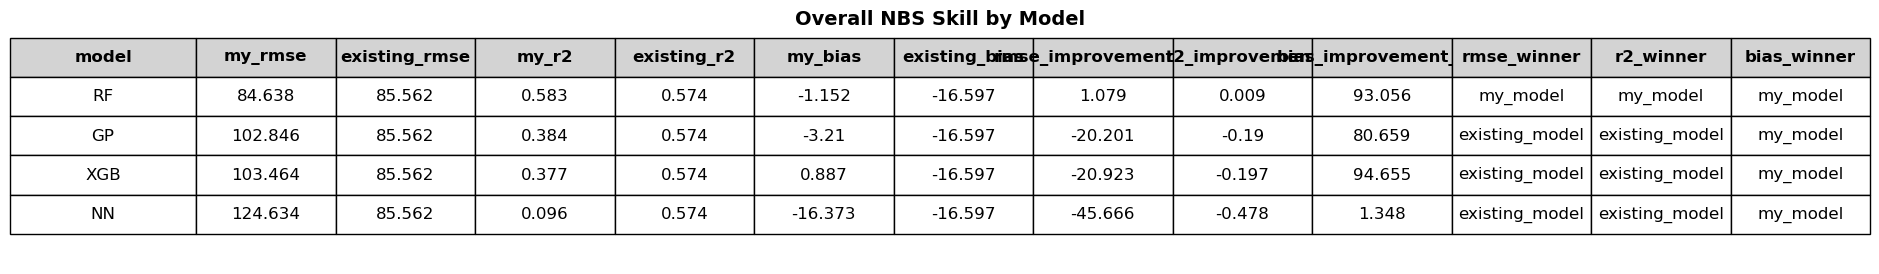

In [7]:
plot_styled_table(overall, title="Overall NBS Skill by Model")

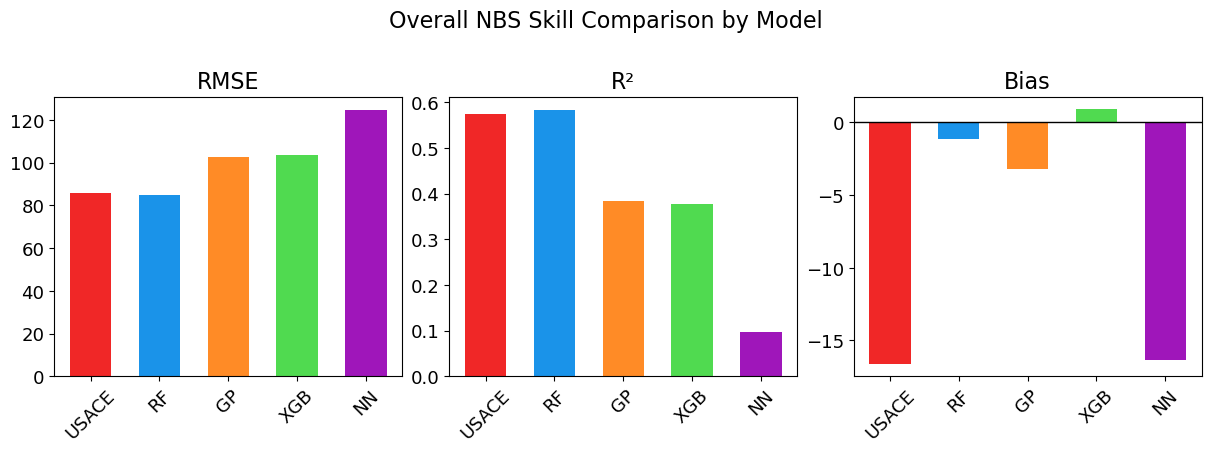

In [18]:
import matplotlib.pyplot as plt

# =========================
# Overall NBS Skill Data
# =========================
models = ["USACE", "RF", "GP", "XGB", "NN"]

rmse = [85.562, 84.638, 102.846, 103.464, 124.634]
r2 = [0.574, 0.583, 0.384, 0.377, 0.096]
bias = [-16.597, -1.152, -3.210, 0.887, -16.373]

# =========================
# Consistent Model Colors
# =========================
model_colors = {
    "USACE": "#f02727",   # gray
    "RF": "#1a93e9",         # blue
    "GP": "#ff8b26",         # orange
    "XGB": "#50da50",        # green
    "NN": "#9f16ba"          # red
}

colors = [model_colors[m] for m in models]

# =========================
# Create Side-by-Side Figure
# =========================
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 3.8),
    constrained_layout=True
)

# -------------------------
# RMSE
# -------------------------
axes[0].bar(models, rmse, color=colors, width=0.6)
axes[0].set_title("RMSE", fontsize=16)
#axes[0].set_ylabel("Error")
axes[0].tick_params(axis='x', rotation=45)

# -------------------------
# R²
# -------------------------
axes[1].bar(models, r2, color=colors, width=0.6)
axes[1].set_title("R²", fontsize=16)
#axes[1].set_ylabel("Skill")
axes[1].tick_params(axis='x', rotation=45)

# -------------------------
# Bias
# -------------------------
axes[2].bar(models, bias, color=colors, width=0.6)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title("Bias", fontsize=16)
#axes[2].set_ylabel("Bias")
axes[2].tick_params(axis='x', rotation=45)

# X-axis tick labels
axes[0].tick_params(axis='x', labelsize=13)
axes[1].tick_params(axis='x', labelsize=13)
axes[2].tick_params(axis='x', labelsize=13)

# Y-axis tick labels
axes[0].tick_params(axis='y', labelsize=13)
axes[1].tick_params(axis='y', labelsize=13)
axes[2].tick_params(axis='y', labelsize=13)

# -------------------------
# Overall Title
# -------------------------
fig.suptitle(
    "Overall NBS Skill Comparison by Model",
    fontsize=16,
    y=1.15
)

plt.show()

In [21]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, r2_score
from properscoring import crps_ensemble


def calc_skill_summary(
    ml_df,
    existing_df,
    variable="nbs",
    lakes=("superior", "michigan-huron", "erie", "ontario"),
    models=("RF", "GP", "XGB", "NN"),
    metrics=("RMSE", "R2", "Bias", "VarRatio", "NSE", "KGE", "CRPS"),
):
    """
    Calculate overall skill metrics for ML models and existing USACE forecasts.

    Parameters
    ----------
    ml_df : pandas.DataFrame
        Forecast dataframe containing:
            - cfs_run
            - model
            - forecast_month
            - prediction columns like "{lake}_{variable}"
            - observation columns like "{lake}_{variable}_obs"

    existing_df : pandas.DataFrame
        Existing forecast dataframe containing:
            - forecast_date
            - year_month
            - prediction columns like "{lake}_{variable}"

    variable : str, default="nbs"
        Variable/component to evaluate, e.g. "nbs", "precipitation", "evaporation", "runoff".

    lakes : tuple
        Lakes to include in the overall skill calculation.

    models : tuple
        ML models to include.

    metrics : tuple
        Skill metrics to calculate.

    Returns
    -------
    pandas.DataFrame
        Summary table with rows = forecast system/model and columns = metrics.
    """

    def calc(metric, obs, pred, ens=None):
        obs = np.asarray(obs, dtype=float)
        pred = np.asarray(pred, dtype=float)

        valid = np.isfinite(obs) & np.isfinite(pred)
        obs = obs[valid]
        pred = pred[valid]

        if len(obs) == 0:
            return np.nan

        if metric == "RMSE":
            return np.sqrt(mean_squared_error(obs, pred))

        if metric == "R2":
            return r2_score(obs, pred)

        if metric == "Bias":
            return np.mean(pred - obs)

        if metric == "VarRatio":
            return np.var(pred) / np.var(obs) if np.var(obs) != 0 else np.nan

        if metric == "NSE":
            denom = np.sum((obs - np.mean(obs)) ** 2)
            return 1 - np.sum((pred - obs) ** 2) / denom if denom != 0 else np.nan

        if metric == "KGE":
            r = np.corrcoef(obs, pred)[0, 1] if len(obs) > 1 else np.nan
            alpha = np.std(pred) / np.std(obs) if np.std(obs) != 0 else np.nan
            beta = np.mean(pred) / np.mean(obs) if np.mean(obs) != 0 else np.nan

            if np.any(np.isnan([r, alpha, beta])):
                return np.nan

            return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

        if metric == "CRPS":
            # Treat deterministic forecasts as one-member ensembles
            ens = pred.reshape(-1, 1)
            return np.mean([crps_ensemble(o, e) for o, e in zip(obs, ens)])

        raise ValueError(f"Unknown metric: {metric}")

    # --------------------------------------------------
    # Standardize dates
    # --------------------------------------------------
    ml = ml_df.copy()
    usace = existing_df.copy()

    ml["cfs_run"] = pd.to_datetime(ml["cfs_run"])
    ml["forecast_month"] = pd.to_datetime(ml["forecast_month"])

    usace["forecast_date"] = pd.to_datetime(usace["forecast_date"])
    usace["year_month"] = pd.to_datetime(usace["year_month"])

    results = []

    # --------------------------------------------------
    # ML model skill
    # --------------------------------------------------
    for model in models:
        df_model = ml[ml["model"] == model].copy()

        obs_all = []
        pred_all = []

        for lake in lakes:
            pred_col = f"{lake}_{variable}"
            obs_col = f"{lake}_{variable}_obs"

            if pred_col not in df_model.columns or obs_col not in df_model.columns:
                continue

            temp = df_model[[pred_col, obs_col]].dropna()

            pred_all.extend(temp[pred_col].to_numpy())
            obs_all.extend(temp[obs_col].to_numpy())

        row = {"model": model}

        for metric in metrics:
            row[metric] = calc(metric, obs_all, pred_all)

        results.append(row)

    # --------------------------------------------------
    # USACE skill
    # --------------------------------------------------
    obs_lookup_cols = ["cfs_run", "forecast_month"]

    obs_cols = [
        f"{lake}_{variable}_obs"
        for lake in lakes
        if f"{lake}_{variable}_obs" in ml.columns
    ]

    obs_lookup = (
        ml[obs_lookup_cols + obs_cols]
        .drop_duplicates(subset=obs_lookup_cols)
        .rename(columns={
            "cfs_run": "forecast_date",
            "forecast_month": "year_month"
        })
    )

    usace_merged = usace.merge(
        obs_lookup,
        on=["forecast_date", "year_month"],
        how="inner"
    )

    obs_all = []
    pred_all = []

    for lake in lakes:
        pred_col = f"{lake}_{variable}"
        obs_col = f"{lake}_{variable}_obs"

        if pred_col not in usace_merged.columns or obs_col not in usace_merged.columns:
            continue

        temp = usace_merged[[pred_col, obs_col]].dropna()

        pred_all.extend(temp[pred_col].to_numpy())
        obs_all.extend(temp[obs_col].to_numpy())

    row = {"model": "USACE"}

    for metric in metrics:
        row[metric] = calc(metric, obs_all, pred_all)

    results.insert(0, row)

    summary = pd.DataFrame(results)

    return summary

In [22]:
skill_summary = calc_skill_summary(
    ml_df=my_model_data,
    existing_df=existing_model_data,
    variable="nbs"
)

skill_summary

,model,RMSE,R2,Bias,VarRatio,NSE,KGE,CRPS
0,USACE,85.561503,0.573771,-16.596522,0.672268,0.573771,0.673902,61.829582
1,RF,83.651395,0.579704,1.376034,0.627831,0.579704,0.683953,61.126677
2,GP,99.386929,0.406710,1.223133,0.961891,0.406710,0.696956,72.240784
3,XGB,97.429650,0.429847,2.692373,0.741930,0.429847,0.650815,70.970372
4,NN,121.751903,0.109651,-9.292003,1.324581,0.109651,0.587425,90.058746


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def plot_skill_summary_table(
    skill_summary,
    model_col="model",
    title="Overall NBS Skill Summary",
    figsize=(11, 3.5),
    save_path=None,
    dpi=300,
    add_star=True,
):
    """
    Plot a presentation-ready skill summary table with heatmap-style coloring.

    Color meaning:
        - Best value for each metric = bright green
        - Other values fade from soft red -> white -> soft green
        - Best value is bolded and optionally marked with a star

    Metric direction:
        Lower is better:
            RMSE, CRPS

        Closer to zero is better:
            Bias

        Higher is better:
            R2, VarRatio, NSE, KGE
    """

    df = skill_summary.copy()

    if model_col in df.columns:
        df = df.set_index(model_col)

    metrics = df.columns.tolist()

    lower_is_better = {"RMSE", "CRPS"}
    absolute_is_better = {"Bias"}
    higher_is_better = {"R2", "VarRatio", "NSE", "KGE"}

    score_df = df.copy()

    # Convert all metrics so that higher score = better
    for metric in metrics:
        if metric in lower_is_better:
            score_df[metric] = -score_df[metric]

        elif metric in absolute_is_better:
            score_df[metric] = -score_df[metric].abs()

        elif metric in higher_is_better:
            score_df[metric] = score_df[metric]

        else:
            score_df[metric] = score_df[metric]

    # Display values
    display_df = df.round(3).astype(str)

    if add_star:
        for metric in metrics:
            valid = np.isfinite(score_df[metric].to_numpy(dtype=float))

            if valid.sum() == 0:
                continue

            best_model = score_df[metric].astype(float).idxmax()
            display_df.loc[best_model, metric] = (
                display_df.loc[best_model, metric] + " ★"
            )

    # Soft gradient for non-winning cells
    soft_cmap = LinearSegmentedColormap.from_list(
        "soft_red_white_green",
        [
            "#f4a6a6",  # soft red
            "#ffffff",  # white
            "#b7e4b7",  # soft green
        ],
    )

    best_color = "#00cc00"  # bright green winner

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=display_df.values,
        rowLabels=display_df.index,
        colLabels=display_df.columns,
        cellLoc="center",
        rowLoc="center",
        loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.15, 2.1)

    # --------------------------------------------------
    # Color metric cells
    # --------------------------------------------------
    for j, metric in enumerate(metrics):
        values = score_df[metric].to_numpy(dtype=float)
        valid = np.isfinite(values)

        if valid.sum() == 0:
            continue

        vmin = np.nanmin(values)
        vmax = np.nanmax(values)

        if vmin == vmax:
            norm_values = np.full_like(values, 0.5, dtype=float)
        else:
            norm_values = (values - vmin) / (vmax - vmin)

        best_idx = np.nanargmax(values)

        for i, norm_val in enumerate(norm_values):
            cell = table[(i + 1, j)]

            if not np.isfinite(norm_val):
                cell.set_facecolor("white")
                cell.set_text_props(color="black")
            elif i == best_idx:
                cell.set_facecolor(best_color)
                cell.set_text_props(color="black")#, weight="bold")
            else:
                cell.set_facecolor(soft_cmap(norm_val))
                cell.set_text_props(color="black")

            cell.set_edgecolor("black")
            cell.set_linewidth(1.0)

    # --------------------------------------------------
    # Style column headers
    # --------------------------------------------------
    for j in range(len(metrics)):
        cell = table[(0, j)]
        cell.set_facecolor("white")
        cell.set_edgecolor("black")
        cell.set_linewidth(1.2)
        cell.set_text_props(color="black", fontsize=14, weight="bold")

    # --------------------------------------------------
    # Style row labels
    # --------------------------------------------------
    for i in range(len(display_df.index)):
        cell = table[(i + 1, -1)]
        cell.set_facecolor("white")
        cell.set_edgecolor("black")
        cell.set_linewidth(1.2)
        cell.set_text_props(color="black", fontsize=14, weight="bold")

    ax.set_title(title, fontsize=18, weight="bold", pad=20)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

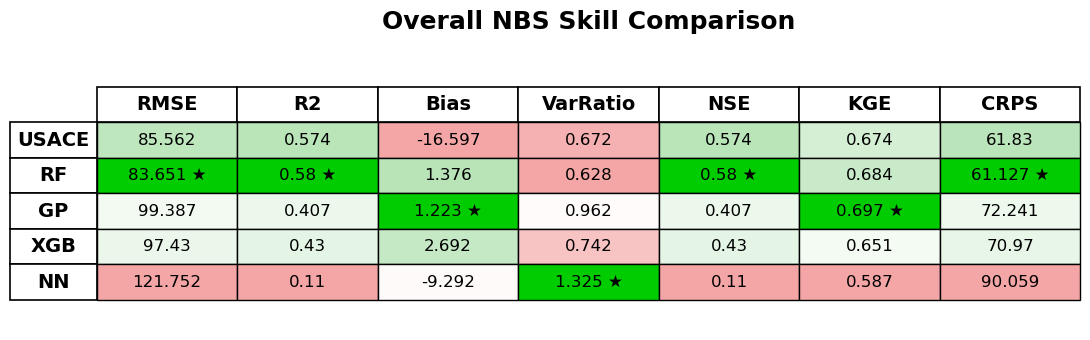

In [44]:
plot_skill_summary_table(
    skill_summary,
    title="Overall NBS Skill Comparison",
    figsize=(11, 3.5),
    save_path="skill_summary_table.png"
)

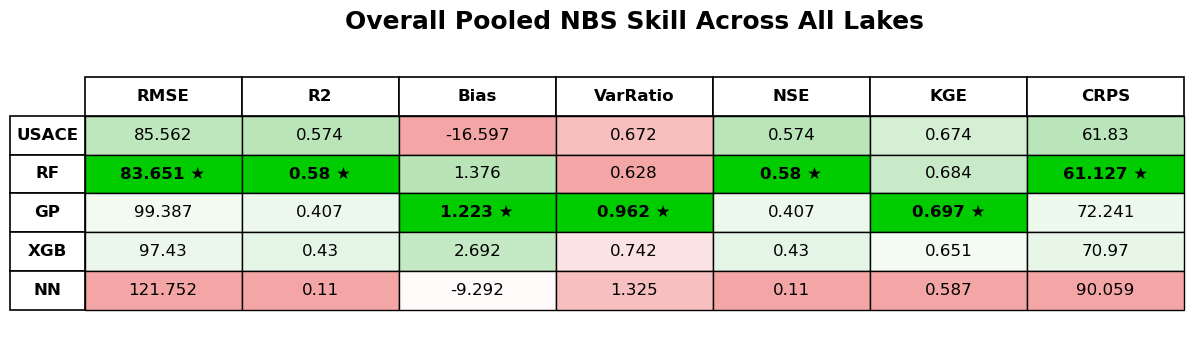

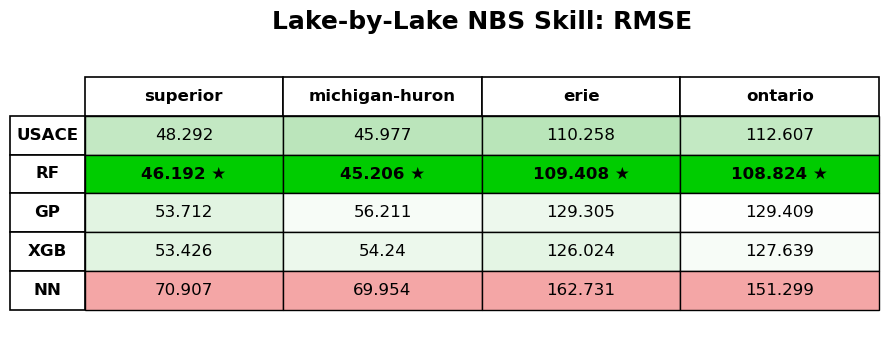

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.metrics import mean_squared_error, r2_score
from properscoring import crps_ensemble


# ============================================================
# 1. Metric calculator
# ============================================================
def calc_metric(metric, obs, pred):
    obs = np.asarray(obs, dtype=float)
    pred = np.asarray(pred, dtype=float)

    valid = np.isfinite(obs) & np.isfinite(pred)
    obs = obs[valid]
    pred = pred[valid]

    if len(obs) == 0:
        return np.nan

    if metric == "RMSE":
        return np.sqrt(mean_squared_error(obs, pred))

    if metric == "R2":
        return r2_score(obs, pred)

    if metric == "Bias":
        return np.mean(pred - obs)

    if metric == "VarRatio":
        return np.var(pred) / np.var(obs) if np.var(obs) != 0 else np.nan

    if metric == "NSE":
        denom = np.sum((obs - np.mean(obs)) ** 2)
        return 1 - np.sum((pred - obs) ** 2) / denom if denom != 0 else np.nan

    if metric == "KGE":
        r = np.corrcoef(obs, pred)[0, 1] if len(obs) > 1 else np.nan
        alpha = np.std(pred) / np.std(obs) if np.std(obs) != 0 else np.nan
        beta = np.mean(pred) / np.mean(obs) if np.mean(obs) != 0 else np.nan

        if np.any(np.isnan([r, alpha, beta])):
            return np.nan

        return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

    if metric == "CRPS":
        ens = pred.reshape(-1, 1)
        return np.mean([crps_ensemble(o, e) for o, e in zip(obs, ens)])

    raise ValueError(f"Unknown metric: {metric}")


# ============================================================
# 2. Build pooled overall skill table
# ============================================================
def calc_overall_pooled_skill(
    ml_df,
    existing_df,
    variable="nbs",
    lakes=("superior", "michigan-huron", "erie", "ontario"),
    models=("RF", "GP", "XGB", "NN"),
    metrics=("RMSE", "R2", "Bias", "VarRatio", "NSE", "KGE", "CRPS"),
):
    ml = ml_df.copy()
    usace = existing_df.copy()

    ml["cfs_run"] = pd.to_datetime(ml["cfs_run"])
    ml["forecast_month"] = pd.to_datetime(ml["forecast_month"])

    usace["forecast_date"] = pd.to_datetime(usace["forecast_date"])
    usace["year_month"] = pd.to_datetime(usace["year_month"])

    results = []

    # -------------------------
    # USACE
    # -------------------------
    obs_cols = [
        f"{lake}_{variable}_obs"
        for lake in lakes
        if f"{lake}_{variable}_obs" in ml.columns
    ]

    obs_lookup = (
        ml[["cfs_run", "forecast_month"] + obs_cols]
        .drop_duplicates(subset=["cfs_run", "forecast_month"])
        .rename(columns={
            "cfs_run": "forecast_date",
            "forecast_month": "year_month",
        })
    )

    usace_merged = usace.merge(
        obs_lookup,
        on=["forecast_date", "year_month"],
        how="inner",
    )

    obs_all = []
    pred_all = []

    for lake in lakes:
        pred_col = f"{lake}_{variable}"
        obs_col = f"{lake}_{variable}_obs"

        if pred_col not in usace_merged.columns or obs_col not in usace_merged.columns:
            continue

        temp = usace_merged[[pred_col, obs_col]].dropna()
        pred_all.extend(temp[pred_col].to_numpy())
        obs_all.extend(temp[obs_col].to_numpy())

    row = {"model": "USACE"}

    for metric in metrics:
        row[metric] = calc_metric(metric, obs_all, pred_all)

    results.append(row)

    # -------------------------
    # ML models
    # -------------------------
    for model in models:
        df_model = ml[ml["model"] == model].copy()

        obs_all = []
        pred_all = []

        for lake in lakes:
            pred_col = f"{lake}_{variable}"
            obs_col = f"{lake}_{variable}_obs"

            if pred_col not in df_model.columns or obs_col not in df_model.columns:
                continue

            temp = df_model[[pred_col, obs_col]].dropna()
            pred_all.extend(temp[pred_col].to_numpy())
            obs_all.extend(temp[obs_col].to_numpy())

        row = {"model": model}

        for metric in metrics:
            row[metric] = calc_metric(metric, obs_all, pred_all)

        results.append(row)

    return pd.DataFrame(results)


# ============================================================
# 3. Build lake-by-lake skill table
# ============================================================
def calc_lake_by_lake_skill(
    ml_df,
    existing_df,
    variable="nbs",
    lakes=("superior", "michigan-huron", "erie", "ontario"),
    models=("USACE", "RF", "GP", "XGB", "NN"),
    metric="RMSE",
):
    ml = ml_df.copy()
    usace = existing_df.copy()

    ml["cfs_run"] = pd.to_datetime(ml["cfs_run"])
    ml["forecast_month"] = pd.to_datetime(ml["forecast_month"])

    usace["forecast_date"] = pd.to_datetime(usace["forecast_date"])
    usace["year_month"] = pd.to_datetime(usace["year_month"])

    results = []

    # -------------------------
    # USACE lake-by-lake
    # -------------------------
    obs_cols = [
        f"{lake}_{variable}_obs"
        for lake in lakes
        if f"{lake}_{variable}_obs" in ml.columns
    ]

    obs_lookup = (
        ml[["cfs_run", "forecast_month"] + obs_cols]
        .drop_duplicates(subset=["cfs_run", "forecast_month"])
        .rename(columns={
            "cfs_run": "forecast_date",
            "forecast_month": "year_month",
        })
    )

    usace_merged = usace.merge(
        obs_lookup,
        on=["forecast_date", "year_month"],
        how="inner",
    )

    row = {"model": "USACE"}

    for lake in lakes:
        pred_col = f"{lake}_{variable}"
        obs_col = f"{lake}_{variable}_obs"

        if pred_col not in usace_merged.columns or obs_col not in usace_merged.columns:
            row[lake] = np.nan
            continue

        temp = usace_merged[[pred_col, obs_col]].dropna()
        row[lake] = calc_metric(
            metric,
            temp[obs_col].to_numpy(),
            temp[pred_col].to_numpy(),
        )

    results.append(row)

    # -------------------------
    # ML model lake-by-lake
    # -------------------------
    for model in [m for m in models if m != "USACE"]:
        df_model = ml[ml["model"] == model].copy()

        row = {"model": model}

        for lake in lakes:
            pred_col = f"{lake}_{variable}"
            obs_col = f"{lake}_{variable}_obs"

            if pred_col not in df_model.columns or obs_col not in df_model.columns:
                row[lake] = np.nan
                continue

            temp = df_model[[pred_col, obs_col]].dropna()
            row[lake] = calc_metric(
                metric,
                temp[obs_col].to_numpy(),
                temp[pred_col].to_numpy(),
            )

        results.append(row)

    return pd.DataFrame(results)


# ============================================================
# 4. Presentation-style heatmap table
# ============================================================
def plot_heatmap_table(
    table_df,
    model_col="model",
    title="Skill Summary",
    figsize=(11, 3.5),
    save_path=None,
    dpi=300,
    lower_is_better=("RMSE", "CRPS"),
    absolute_is_better = {"Bias"},
    target_one_is_better = {"VarRatio"},
    higher_is_better = {"R2", "NSE", "KGE"},
    add_star=True,
):
    df = table_df.copy()

    if model_col in df.columns:
        df = df.set_index(model_col)

    columns = df.columns.tolist()

    score_df = df.copy()

    # Convert all columns so higher score = better
    for col in columns:
        if col in lower_is_better:
            score_df[col] = -score_df[col]

        elif col in absolute_is_better:
            score_df[col] = -score_df[col].abs()

        # Closest to one is best
        elif col in target_one_is_better:
            score_df[col] = -np.abs(score_df[col] - 1)
    
        elif col in higher_is_better:
            score_df[col] = score_df[col]

        else:
            # For lake-by-lake RMSE tables, pass lower_is_better=columns
            score_df[col] = score_df[col]

    display_df = df.round(3).astype(str)

    if add_star:
        for col in columns:
            values = score_df[col].to_numpy(dtype=float)
            valid = np.isfinite(values)

            if valid.sum() == 0:
                continue

            best_model = score_df[col].astype(float).idxmax()
            display_df.loc[best_model, col] = display_df.loc[best_model, col] + " ★"

    soft_cmap = LinearSegmentedColormap.from_list(
        "soft_red_white_green",
        [
            "#f4a6a6",  # soft red
            "#ffffff",  # white
            "#b7e4b7",  # soft green
        ],
    )

    best_color = "#00cc00"

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=display_df.values,
        rowLabels=display_df.index,
        colLabels=display_df.columns,
        cellLoc="center",
        rowLoc="center",
        loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.15, 2.3)

    for j, col in enumerate(columns):
        values = score_df[col].to_numpy(dtype=float)
        valid = np.isfinite(values)

        if valid.sum() == 0:
            continue

        vmin = np.nanmin(values)
        vmax = np.nanmax(values)

        if vmin == vmax:
            norm_values = np.full_like(values, 0.5, dtype=float)
        else:
            norm_values = (values - vmin) / (vmax - vmin)

        best_idx = np.nanargmax(values)

        for i, norm_val in enumerate(norm_values):
            cell = table[(i + 1, j)]

            if not np.isfinite(norm_val):
                cell.set_facecolor("white")
                cell.set_text_props(color="black")
            elif i == best_idx:
                cell.set_facecolor(best_color)
                cell.set_text_props(color="black", weight="bold")
            else:
                cell.set_facecolor(soft_cmap(norm_val))
                cell.set_text_props(color="black")

            cell.set_edgecolor("black")
            cell.set_linewidth(1.0)

    # Column headers
    for j in range(len(columns)):
        cell = table[(0, j)]
        cell.set_facecolor("white")
        cell.set_edgecolor("black")
        cell.set_linewidth(1.2)
        cell.set_text_props(color="black", weight="bold")

    # Row labels
    for i in range(len(display_df.index)):
        cell = table[(i + 1, -1)]
        cell.set_facecolor("white")
        cell.set_edgecolor("black")
        cell.set_linewidth(1.2)
        cell.set_text_props(color="black", weight="bold")

    ax.set_title(title, fontsize=18, weight="bold", pad=20)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


# ============================================================
# 5. Example usage
# ============================================================

# Overall pooled NBS skill table
overall_skill = calc_overall_pooled_skill(
    ml_df=my_model_data,
    existing_df=existing_model_data,
    variable="nbs",
)

plot_heatmap_table(
    overall_skill,
    title="Overall Pooled NBS Skill Across All Lakes",
    figsize=(12, 3.5),
    save_path="overall_pooled_nbs_skill.png",
)

# Lake-by-lake NBS heatmap using RMSE
lake_skill_rmse = calc_lake_by_lake_skill(
    ml_df=my_model_data,
    existing_df=existing_model_data,
    variable="nbs",
    metric="RMSE",
)

plot_heatmap_table(
    lake_skill_rmse,
    title="Lake-by-Lake NBS Skill: RMSE",
    figsize=(9, 3.5),
    save_path="lake_by_lake_nbs_rmse.png",
    lower_is_better=lake_skill_rmse.drop(columns="model").columns.tolist(),
    higher_is_better=(),
    absolute_is_better=(),
)